# 03 - Customer Segmentation

## E-Commerce Personalization Using EM Clustering and Deep Recommendation

### Objective

This notebook transforms cleaned transaction-level data into
customer-level behavioural profiles that can be used for
customer segmentation and subsequent EM/GMM clustering.

### Main Tasks

- Load the cleaned transaction data
- Construct customer-level behavioural features
- Examine the resulting customer profiles
- Handle feature distributions where necessary
- Normalize / standardize the segmentation variables
- Prepare the final feature matrix for EM/GMM clustering

### Key Features

The segmentation framework considers customer behaviour using features
such as:

- Number of Purchases
- Total Quantity
- Total Spending
- Average Unit Price

In [1]:
# Necessary libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
DATA_PATH = "cleaned_data.csv"

customer_features = pd.read_csv(DATA_PATH)

print("Dataset first 5 rows:")
customer_features.head()

Dataset first 5 rows:


,CustomerID,NumPurchases,TotalQuantity,TotalSpending,AvgUnitPrice
0,12346.0,1,74215,77183.60,1.040000
1,12347.0,7,2458,4310.00,2.644011
2,12348.0,4,2341,1797.24,5.764839
3,12349.0,1,631,1757.55,8.289041
4,12350.0,1,197,334.40,3.841176


In [2]:
# Inspect the columns
print(customer_features.columns.tolist())

['CustomerID', 'NumPurchases', 'TotalQuantity', 'TotalSpending', 'AvgUnitPrice']


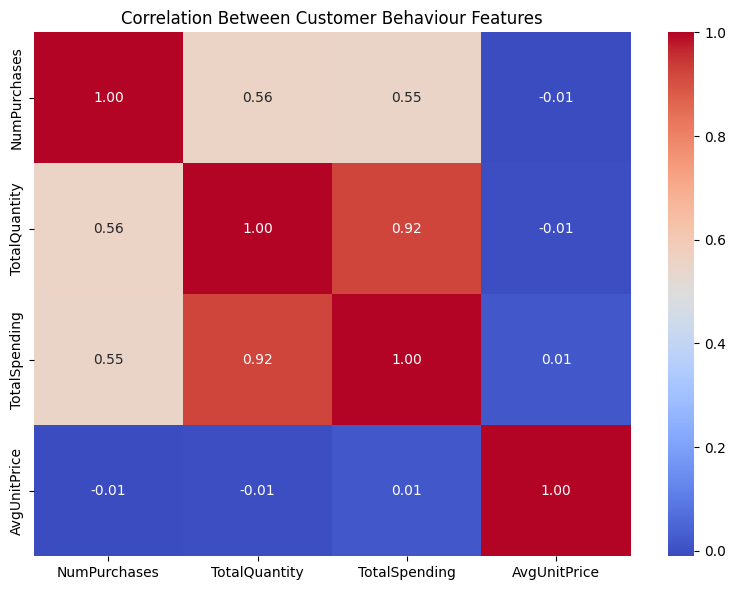

In [3]:
# Correlation between the customer features
import matplotlib.pyplot as plt
import seaborn as sns

features = ["NumPurchases", "TotalQuantity", "TotalSpending", "AvgUnitPrice"]
plt.figure(figsize=(8, 6))

sns.heatmap(
    customer_features[features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Customer Behaviour Features")
plt.tight_layout()

plt.savefig(
    "Correlation_btn_customer_behavior_features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Correlation Analysis Findings

The correlation analysis was conducted to examine the relationships
among the selected customer behavioural features before clustering.

The results reveal a strong positive correlation between
**TotalQuantity** and **TotalSpending** (r = 0.92), indicating that
customers who purchase larger quantities generally account for higher
total spending.

**NumPurchases** shows moderate positive correlations with
**TotalQuantity** (r = 0.56) and **TotalSpending** (r = 0.55),
suggesting that purchase frequency is also associated with overall
customer activity and spending.

In contrast, **AvgUnitPrice** shows near-zero correlations with the
other behavioural variables, indicating that average unit price has
little linear association with purchase frequency, total quantity,
or total spending within the analyzed customer profiles.

The strong association between TotalQuantity and TotalSpending
suggests some feature redundancy, which should be considered during
the subsequent clustering stage. Nevertheless, both variables are
retained because they represent distinct behavioural dimensions:
purchase volume and monetary value.

These findings provide a basis for the subsequent feature
standardization and Expectation-Maximization / Gaussian Mixture Model
clustering analysis.

## Feature Interpretation

The customer-level feature matrix represents purchasing behaviour at
the individual-customer level.

- **NumPurchases** represents purchase frequency.
- **TotalQuantity** represents the overall quantity purchased.
- **TotalSpending** represents the customer's total transaction value.
- **AvgUnitPrice** represents the average unit price associated with
  the customer's transactions.

These features provide the behavioural representation required for
the subsequent clustering stage.

In [4]:
# Standardize the clustering variables
scaler = StandardScaler()

X = customer_features[features]

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=customer_features.index
)

display(X_scaled.head())

,NumPurchases,TotalQuantity,TotalSpending,AvgUnitPrice
0,-0.425097,14.480825,8.363010,-0.100284
1,0.354417,0.251903,0.251699,-0.053398
2,-0.035340,0.228702,-0.027988,0.037825
3,-0.425097,-0.110379,-0.032406,0.111608
4,-0.425097,-0.196438,-0.190812,-0.018405


In [5]:
# Inspect the standardized data
display(X_scaled.describe().T)

,count,mean,std,min,25%,50%,75%,max
NumPurchases,4338.0,1.801745e-17,1.000115,-0.425097,-0.425097,-0.295178,0.094579,26.598031
TotalQuantity,4338.0,2.784515e-17,1.000115,-0.235303,-0.203973,-0.160547,-0.039241,38.811396
TotalSpending,4338.0,1.965540e-17,1.000115,-0.227615,-0.193919,-0.153616,-0.043197,30.960742
AvgUnitPrice,4338.0,1.801745e-17,1.000115,-0.127103,-0.066189,-0.045394,-0.018657,59.297431


In [6]:
# Prepare and save customer-level features
# Save the feature table
customer_features.to_csv(
    "customer_features.csv",
    index=False
)

In [7]:
# Save the scaled matrix
X_scaled.to_csv(
    "customer_features_scaled.csv",
    index=False
)

## Output of Notebook 3

This notebook produces two key analytical outputs:

1. `customer_features.csv`
   - Customer-level behavioural features.

2. `customer_features_scaled.csv`
   - Standardized features prepared for the clustering stage.

These outputs are used as inputs to Notebook 4, where
Expectation-Maximization / Gaussian Mixture Model clustering is
performed and evaluated.